<a href="https://colab.research.google.com/github/Flavio-98/Projeto_DataScience_ANAC_Tarifas/blob/main/Projeto_Aplicado_ANAC_Etapa3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**


# **Entrega 3**

---

# **Análise Preditiva de Tarifas Aéreas Brasileiras: Uma Abordagem via Modelo SARIMA (2022-2025)**
---

In [ ]:
#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: , *)
Aluno1 = 'Flavio Estevam Nogueira Andrade, 10441572' #@param {type:"string"}
Aluno2 = 'Kaique Nascimento de Paula, 24024831' #@param {type:"string"}
Aluno3 = 'Miguel Shiraishi, 10431805' #@param {type:"string"}
Aluno4 = 'Moacyr Souza Barros, 10441179' #@param {type:"string"}



# **Introdução**

**1.1 Contexto**

O setor aéreo brasileiro é dominado por três grandes empresas: Azul, Gol e Latam. Após o período crítico da pandemia, o mercado passou por uma fase de reorganização, enfrentando mudanças na demanda dos passageiros e custos operacionais variados. Para entender como o setor está hoje, a ANAC (Agência Nacional de Aviação Civil) disponibiliza microdados detalhados sobre todas as tarifas comercializadas no país. Para a realização deste projeto, foram utilizados microdados tarifários brutos extraídos do portal oficial da ANAC. A base completa, composta pelos arquivos CSV consolidados para a análise, está armazenada e disponível para conferência através do seguinte link: https://drive.google.com/drive/folders/1BoLlqGzr8HVCwM1OV2yucq2RszoV8vvh?usp=drive_link

**1.2 Motivação**

A principal motivação deste trabalho é aplicar as técnicas de Ciência de Dados aprendidas no curso para transformar uma base de dados bruta e volumosa em informações visuais. Observar como o equilíbrio de forças entre as três principais companhias aéreas do país e como isso reflete no custo do consumidor. Analisar esses dados permite identificar padrões que não são óbvios apenas lendo notícias ou sites de vendas.

**1.3 Objetivos**

1.3.1 Objetivo Geral

- Analisar o comportamento do mercado de aviação civil nacional entre os anos de 2022 e 2025, focando na participação de mercado e na evolução dos preços das passagens das três principais companhias aéreas.

1.3.2 Objetivos Específicos

- Tratamento de Dados: Utilizar a biblioteca Pandas para filtrar e limpar a base de dados da ANAC, focando apenas nos voos domésticos das empresas alvo.

- Análise de Market Share: Calcular e visualizar a fatia de mercado de cada companhia através de gráficos de setores (pizza).

- Análise Temporal: Gerar gráficos de linha para acompanhar a variação mensal do preço médio das passagens, identificando tendências e sazonalidade.

- Comparação de Performance: Confrontar os dados das três empresas para entender qual delas manteve maior estabilidade de preços e volume de vendas no período.

**1.4 Justificativa**

Este projeto se justifica pela necessidade de monitorar a concentração de mercado em um setor essencial para a economia brasileira. Com a saída de empresas menores e os desafios financeiros das grandes companhias, entender como o market share se distribui e como os preços reagem é fundamental para a análise econômica do setor. Tecnicamente, o projeto justifica-se pelo desafio de manipular grandes volumes de dados provenientes da ANAC, exigindo o uso eficiente de bibliotecas de processamento de dados em Python, como o Pandas, para gerar insights que ferramentas comuns de escritório não suportariam com facilidade.

# **Referencial Teórico**

O foco central deste trabalho é a análise do comportamento dos preços das passagens aéreas, um indicador fundamental para entender a acessibilidade do transporte aéreo e as estratégias das companhias aéreas. O conceito principal envolve o monitoramento da tarifa aérea média doméstica, que reflete as variações de custo conforme a sazonalidade, a demanda e a concorrência entre as empresas (ANAC, 2024). Ao discutir trabalhos correlacionados, nota-se que estudos do setor costumam focar em indicadores macroeconômicos ou relatórios anuais consolidados, muitas vezes utilizando ferramentas de Business Intelligence (BI) ou planilhas eletrônicas como o Excel para o tratamento dos dados. Embora o uso de planilhas seja uma alternativa comum para problemas semelhantes, essa abordagem apresenta limitações críticas de performance e escalabilidade ao processar o volume massivo de microdados tarifários disponibilizados pela ANAC. Em contrapartida, a solução proposta utiliza a linguagem Python e a biblioteca Pandas, oferecendo a vantagem de automatizar o pipeline de limpeza e permitir uma análise temporal granular e precisa. Além do foco nos preços, utiliza-se o conceito de Market Share como uma variável secundária para observar se a concentração de mercado entre as três principais operadoras influencia diretamente na flutuação das tarifas praticadas (MCKINNEY, 2022). Dessa forma, o projeto utiliza técnicas modernas de Ciência de Dados para superar as restrições de ferramentas manuais, garantindo maior reprodutibilidade e profundidade na análise do mercado aéreo.



# **Diagrama de Solução**
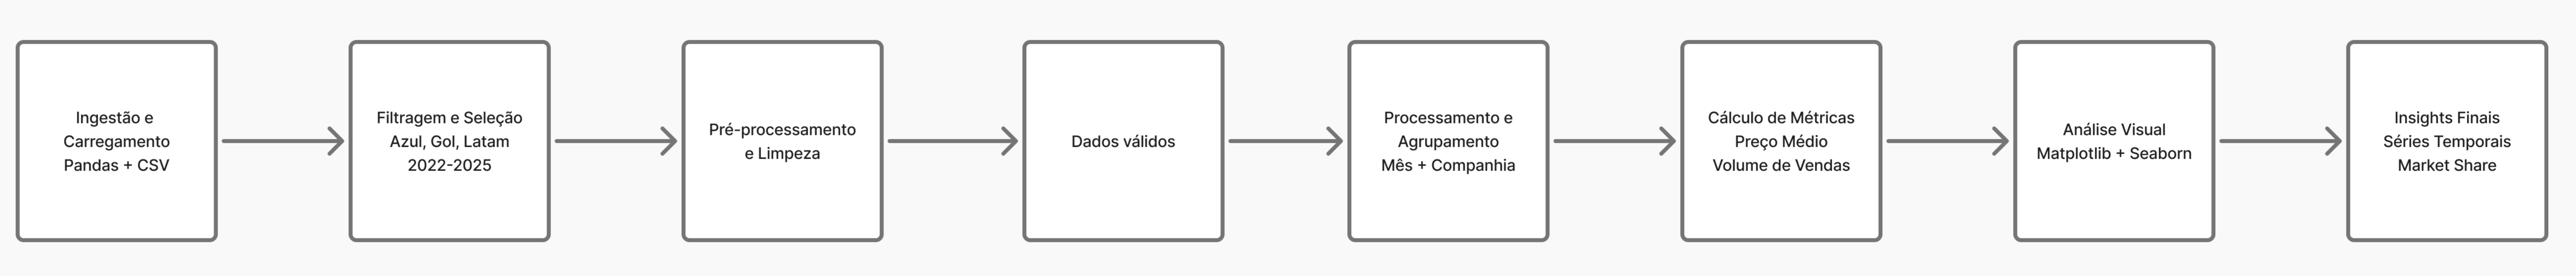


# **EDA e Pré-processamento dos dados**

A base analisada possui mais de 26 milhões de registros, exigindo um processo estruturado de preparação para garantir qualidade e consistência dos dados.

**Preparação dos Dados**

As principais etapas realizadas foram:

- Padronização de dados provenientes de múltiplos arquivos mensais
Conversão de variáveis críticas (datas e valores monetários)
Tratamento de inconsistências e registros inválidos
Normalização das estruturas para garantir comparabilidade ao longo do tempo
Controle de outliers para reduzir distorções estatísticas

- A agregação mensal foi adotada como estratégia para transformar dados operacionais em uma série temporal estável e adequada para modelagem.

**Análise Exploratória**

A análise evidenciou padrões relevantes:

- Tendência de crescimento das tarifas no período pós-pandemia
- Indícios de sazonalidade, compatíveis com ciclos do setor aéreo
- Distribuição assimétrica, com presença de valores extremos
- Diferenças entre companhias, refletindo estratégias distintas de precificação

Esses fatores confirmam que a série possui características adequadas para modelagem de séries temporais.

In [ ]:
import pandas as pd
import numpy as np
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

caminho_pasta = '/content/drive/MyDrive/Projeto_anac/'


arquivos_zips = [f for f in os.listdir(caminho_pasta) if f.lower().endswith('.zip')]

primeiro_zip = os.path.join(caminho_pasta, arquivos_zips[0])

with zipfile.ZipFile(primeiro_zip, 'r') as z:
    primeiro_csv = z.namelist()[0]
    with z.open(primeiro_csv) as f:
        amostra = pd.read_csv(f, sep=';', encoding='latin1', nrows=5)

print(f"Arquivo analisado: {primeiro_csv}")
print("\nColunas encontradas:")
print(amostra.columns.tolist())
display(amostra.head())

Mounted at /content/drive
Arquivo analisado: 202201.CSV

Colunas encontradas:
['Ano de Referência', 'Mês de Referência', 'ICAO Empresa Aérea', 'ICAO Aeródromo Origem', 'ICAO Aeródromo Destino', 'Tarifa-N', 'Assentos Comercializados']


,Ano de Referência,Mês de Referência,ICAO Empresa Aérea,ICAO Aeródromo Origem,ICAO Aeródromo Destino,Tarifa-N,Assentos Comercializados
0,2022,1,AZU,SBAC,SBAR,"552,9",1
1,2022,1,AZU,SBAC,SBBR,"614,9",1
2,2022,1,AZU,SBAC,SBCA,"550,9",1
3,2022,1,AZU,SBAC,SBCF,"887,9",1
4,2022,1,AZU,SBAC,SBFL,"438,9",3


In [ ]:
lista_dfs = []

def identificar_colunas(colunas):
    mapa = {}
    for c in colunas:
        c_low = c.lower()
        if 'ano' in c_low or 'nr_ano' in c_low:
            mapa[c] = 'ano'
        elif 'mês' in c_low or 'mes' in c_low or 'nr_mes' in c_low:
            mapa[c] = 'mes'
        elif 'empresa' in c_low or 'sg_empresa' in c_low:
            mapa[c] = 'empresa'
        elif 'origem' in c_low or 'sg_origem' in c_low:
            mapa[c] = 'origem'
        elif 'destino' in c_low or 'sg_destino' in c_low:
            mapa[c] = 'destino'
        elif 'tarifa' in c_low or 'vl_tarifa' in c_low:
            mapa[c] = 'tarifa'
    return mapa

for zip_nome in arquivos_zips:
    with zipfile.ZipFile(os.path.join(caminho_pasta, zip_nome), 'r') as z:
        for csv_nome in z.namelist():
            if csv_nome.lower().endswith('.csv'):
                with z.open(csv_nome) as f:
                    content_preview = f.read(2048).decode('latin1', errors='ignore')
                    sep = ';' if ';' in content_preview else ','
                    f.seek(0)

                    df = pd.read_csv(f, sep=sep, engine='python', encoding='latin1', dtype=str)

                    mapa_cols = identificar_colunas(df.columns)
                    df = df.rename(columns=mapa_cols)

                    manter = ['ano', 'mes', 'empresa', 'origem', 'destino', 'tarifa']
                    cols_presentes = [c for c in manter if c in df.columns]

                    if len(cols_presentes) >= 5:
                        lista_dfs.append(df[cols_presentes].copy())
                        print(f"OK: {csv_nome}")

df_completo = pd.concat(lista_dfs, ignore_index=True)

for col in ['ano', 'mes']:
    df_completo[col] = pd.to_numeric(df_completo[col], errors='coerce').astype('Int16')

if 'tarifa' in df_completo.columns:
    df_completo['tarifa'] = df_completo['tarifa'].str.replace(',', '.')
    df_completo['tarifa'] = pd.to_numeric(df_completo['tarifa'], errors='coerce').astype('float32')

print(f"\n--- DADOS CORRIGIDOS ---")
print(f"Total: {len(df_completo)} linhas")
print("\nAnos:", df_completo['ano'].unique().tolist())
print("Meses:", sorted([m for m in df_completo['mes'].unique() if m is not pd.NA]))
display(df_completo.head())

OK: 202201.CSV
OK: 202202.CSV
OK: 202203.CSV
OK: 202204.CSV
OK: 202205.CSV
OK: 202206.CSV
OK: 202207.CSV
OK: 202208.CSV
OK: 202209.CSV
OK: 202210.CSV
OK: 202211.CSV
OK: 202212.CSV
OK: 202301.CSV
OK: 202302.CSV
OK: 202303.CSV
OK: 202304.CSV
OK: 202305.CSV
OK: 202306.CSV
OK: 202307.CSV
OK: 202308.CSV
OK: 202309.CSV
OK: 202310.CSV
OK: 202311.CSV
OK: 202312.CSV
OK: 202401.CSV
OK: 202402.CSV
OK: 202403.CSV
OK: 202404.CSV
OK: 202405.CSV
OK: 202406.CSV
OK: 202407.CSV
OK: 202408.CSV
OK: 202409.CSV
OK: 202410.CSV
OK: 202411.CSV
OK: 202412.CSV
OK: 202501.CSV
OK: 202502.CSV
OK: 202503.CSV
OK: 202504.CSV
OK: 202505.CSV
OK: 202506.CSV
OK: 202507.CSV
OK: 202508.CSV
OK: 202509.CSV
OK: 202510.CSV
OK: 202511.CSV
OK: 202512.CSV

--- DADOS CORRIGIDOS ---
Total: 26297368 linhas

Anos: [2022, 2023, 2024, 2025]
Meses: [np.int16(1), np.int16(2), np.int16(3), np.int16(4), np.int16(5), np.int16(6), np.int16(7), np.int16(8), np.int16(9), np.int16(10), np.int16(11), np.int16(12)]


,ano,mes,empresa,origem,destino,tarifa
0,2022,1,AZU,SBAC,SBAR,552.900024
1,2022,1,AZU,SBAC,SBBR,614.900024
2,2022,1,AZU,SBAC,SBCA,550.900024
3,2022,1,AZU,SBAC,SBCF,887.900024
4,2022,1,AZU,SBAC,SBFL,438.899994


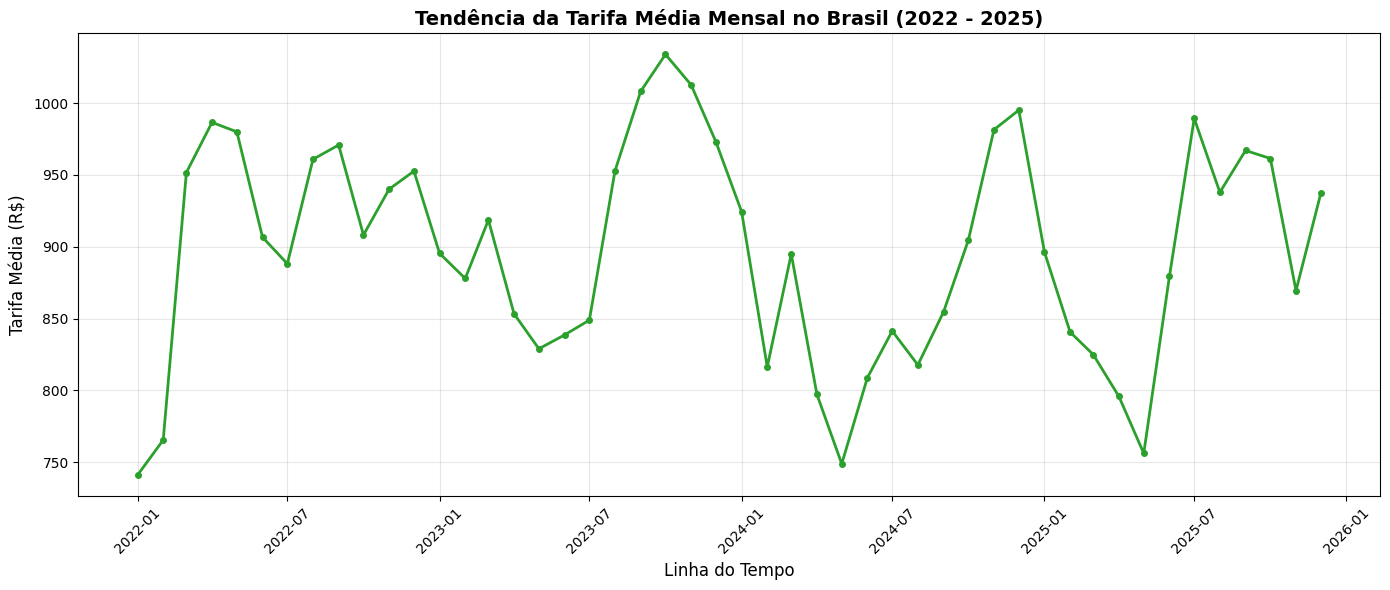

In [ ]:
df_completo['data'] = pd.to_datetime(df_completo['ano'].astype(str) + '-' + df_completo['mes'].astype(str) + '-01')

serie_temporal = df_completo.groupby('data')['tarifa'].mean()

plt.figure(figsize=(14, 6))
plt.plot(serie_temporal.index, serie_temporal.values, color='#2ca02c', marker='o', linestyle='-', linewidth=2, markersize=4)

plt.title('Tendência da Tarifa Média Mensal no Brasil (2022 - 2025)', fontsize=14, fontweight='bold')
plt.ylabel('Tarifa Média (R$)', fontsize=12)
plt.xlabel('Linha do Tempo', fontsize=12)
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

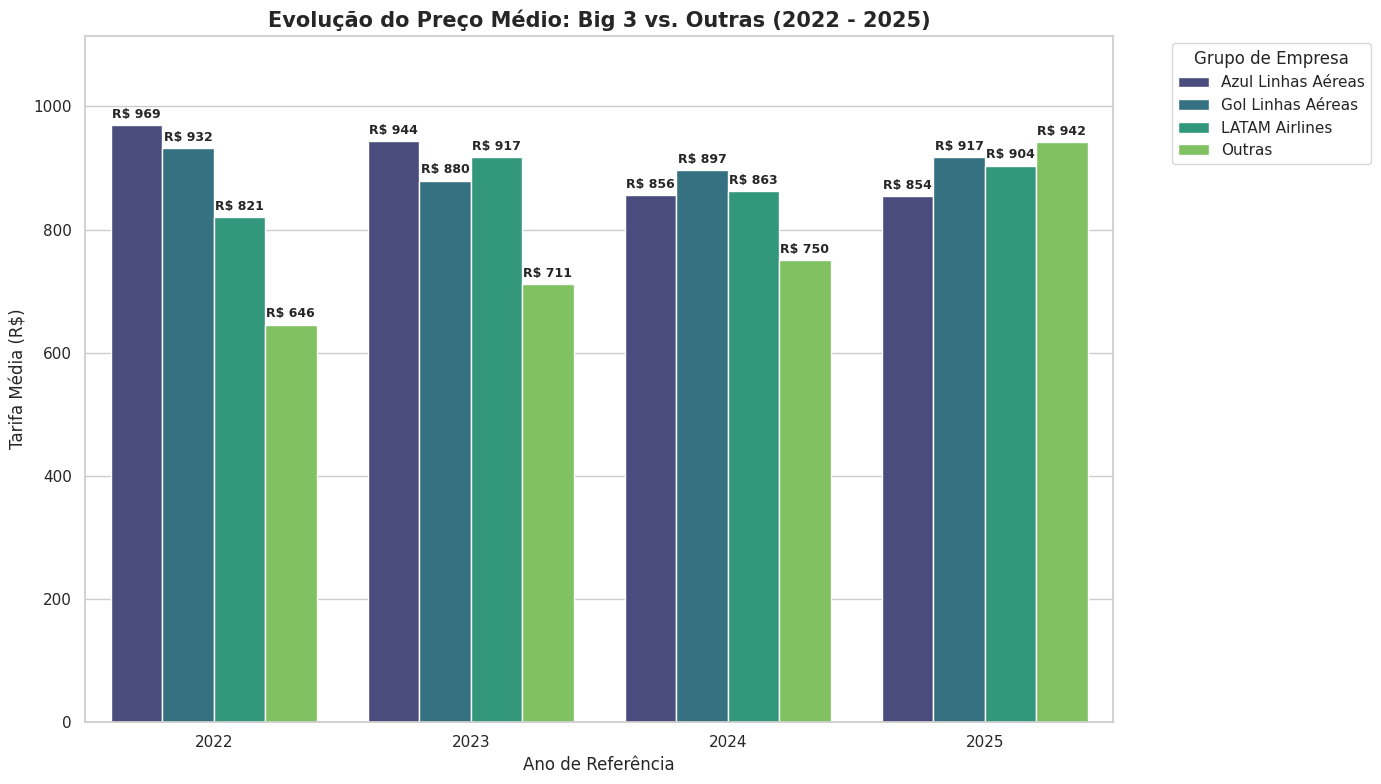

In [ ]:

gigantes = ['AZU', 'GLO', 'TAM']
nomes_map = {
    'AZU': 'Azul Linhas Aéreas',
    'GLO': 'Gol Linhas Aéreas',
    'TAM': 'LATAM Airlines'
}

df_completo['empresa_agrupada'] = df_completo['empresa'].apply(
    lambda x: nomes_map.get(x, x) if x in gigantes else 'Outras'
)

df_anual = df_completo.groupby(['ano', 'empresa_agrupada'])['tarifa'].mean().reset_index()

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

grafico = sns.barplot(
    data=df_anual,
    x='ano',
    y='tarifa',
    hue='empresa_agrupada',
    palette='viridis'
)

for container in grafico.containers:
    grafico.bar_label(container, fmt='R$ %.0f', padding=3, fontsize=9, fontweight='bold')

plt.title('Evolução do Preço Médio: Big 3 vs. Outras (2022 - 2025)', fontsize=15, fontweight='bold')
plt.ylabel('Tarifa Média (R$)', fontsize=12)
plt.xlabel('Ano de Referência', fontsize=12)
plt.legend(title='Grupo de Empresa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, df_anual['tarifa'].max() * 1.15)

plt.tight_layout()
plt.show()

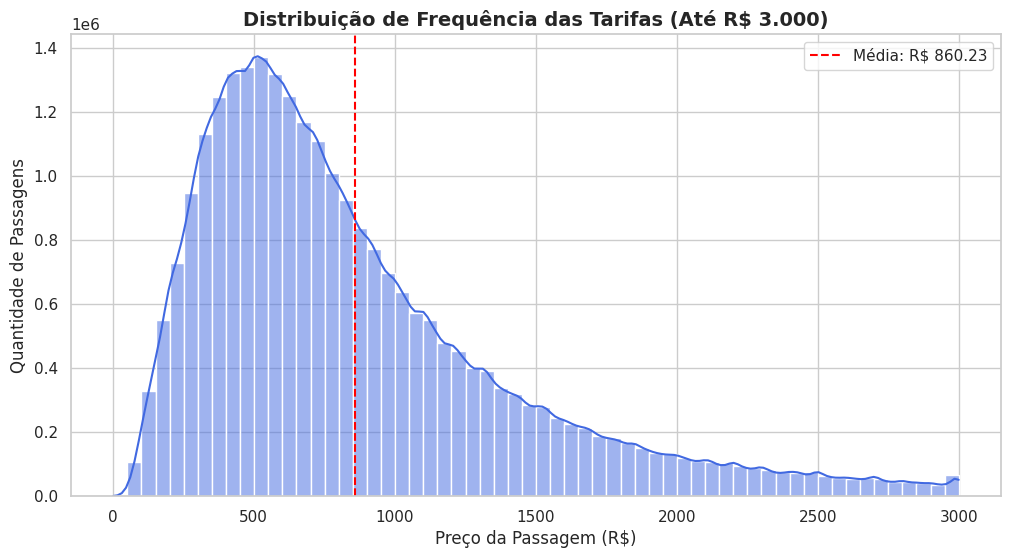

In [ ]:
df_filtrado = df_completo[df_completo['tarifa'] < 3000].copy()
media_val = df_filtrado['tarifa'].mean()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.histplot(data=df_filtrado, x='tarifa', kde=True, bins=60, color='royalblue')

plt.axvline(media_val, color='red', linestyle='--', label=f'Média: R$ {media_val:.2f}')

plt.title('Distribuição de Frequência das Tarifas (Até R$ 3.000)', fontsize=14, fontweight='bold')
plt.xlabel('Preço da Passagem (R$)', fontsize=12)
plt.ylabel('Quantidade de Passagens', fontsize=12)
plt.legend()

plt.show()

/tmp/ipykernel_3655/2755075348.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


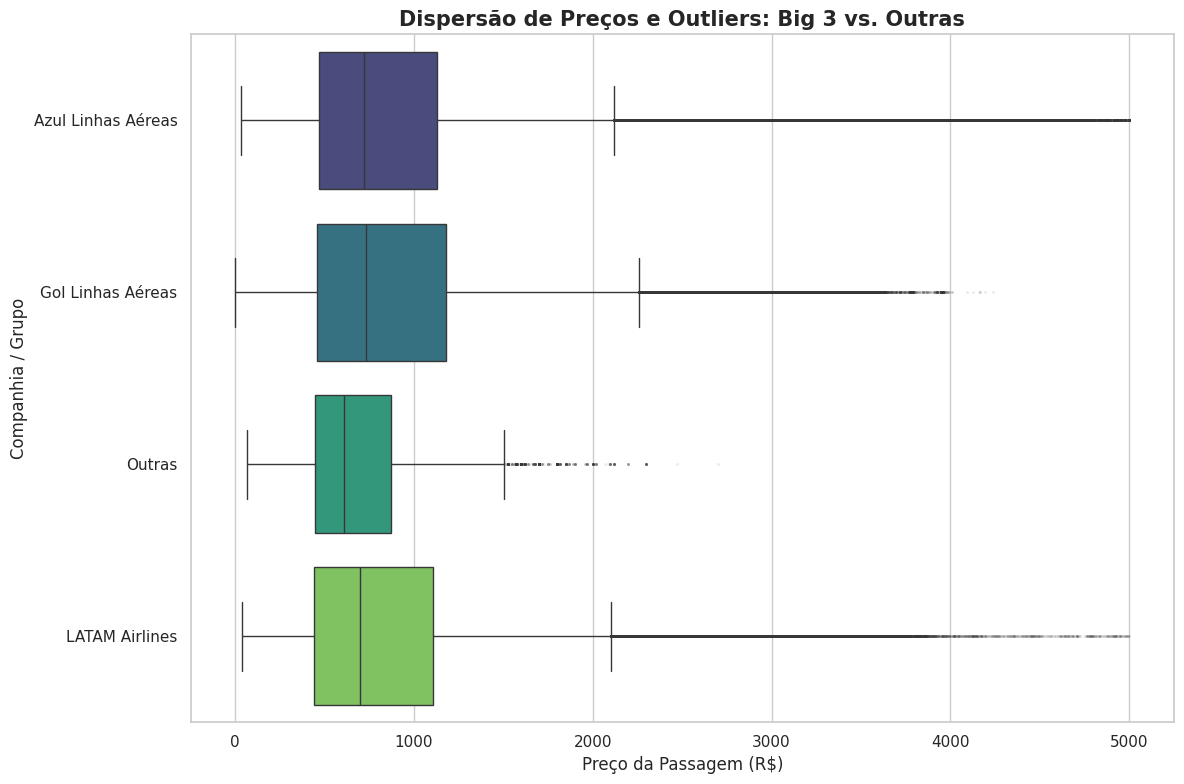

In [ ]:
df_box = df_completo[df_completo['tarifa'] < 5000].copy()

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df_box,
    x='tarifa',
    y='empresa_agrupada',
    palette='viridis',
    showfliers=True,
    flierprops={"marker": "o", "markersize": 1, "alpha": 0.1}
)

plt.title('Dispersão de Preços e Outliers: Big 3 vs. Outras', fontsize=15, fontweight='bold')
plt.xlabel('Preço da Passagem (R$)', fontsize=12)
plt.ylabel('Companhia / Grupo', fontsize=12)

plt.tight_layout()
plt.show()

# **Modelo base**

Com base nos padrões identificados, foi adotado o modelo SARIMA (Seasonal ARIMA) como abordagem inicial.

A escolha se justifica por:

- Estrutura temporal consistente
- Presença de tendência
- Indícios de sazonalidade mensal
- O modelo atua como baseline, permitindo capturar a dinâmica central da série antes da aplicação de abordagens mais avançadas.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

serie_temporal = df_completo.groupby('data')['tarifa'].mean()

serie_temporal.index = pd.to_datetime(serie_temporal.index)
serie_temporal = serie_temporal.sort_index()

train = serie_temporal[serie_temporal.index.year < 2025]
test = serie_temporal[serie_temporal.index.year == 2025]

model = SARIMAX(train,
                order=(1,1,1),
                seasonal_order=(1,1,1,12),
                enforce_stationarity=False,
                enforce_invertibility=False)

resultado = model.fit(disp=False)

pred = resultado.predict(start=test.index[0], end=test.index[-1])

rmse = np.sqrt(mean_squared_error(test, pred))
print(f'RMSE: {rmse:.2f}')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


RMSE: 106.03


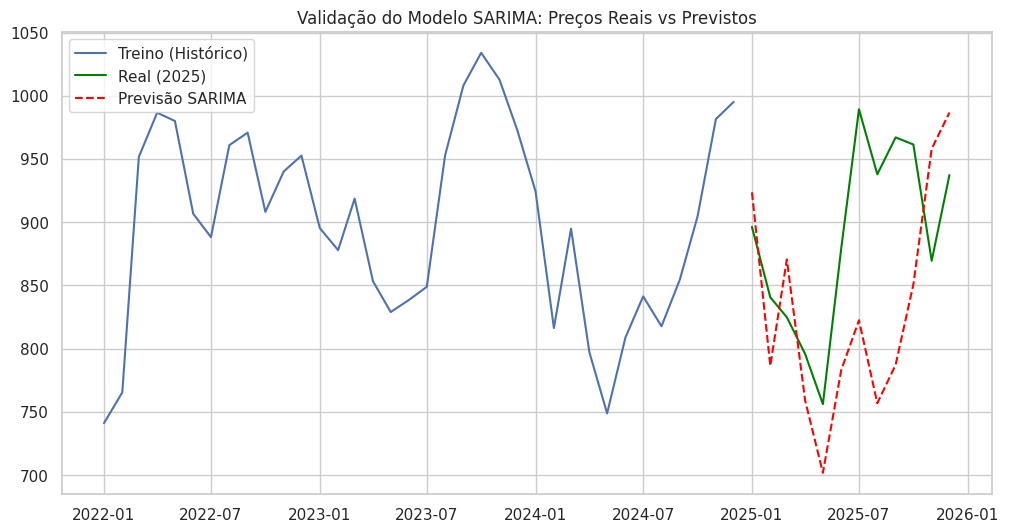

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Treino (Histórico)')
plt.plot(test.index, test, label='Real (2025)', color='green')
plt.plot(test.index, pred, label='Previsão SARIMA', color='red', linestyle='--')
plt.title('Validação do Modelo SARIMA: Preços Reais vs Previstos')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Métrica de Erro - RMSE: 106.03


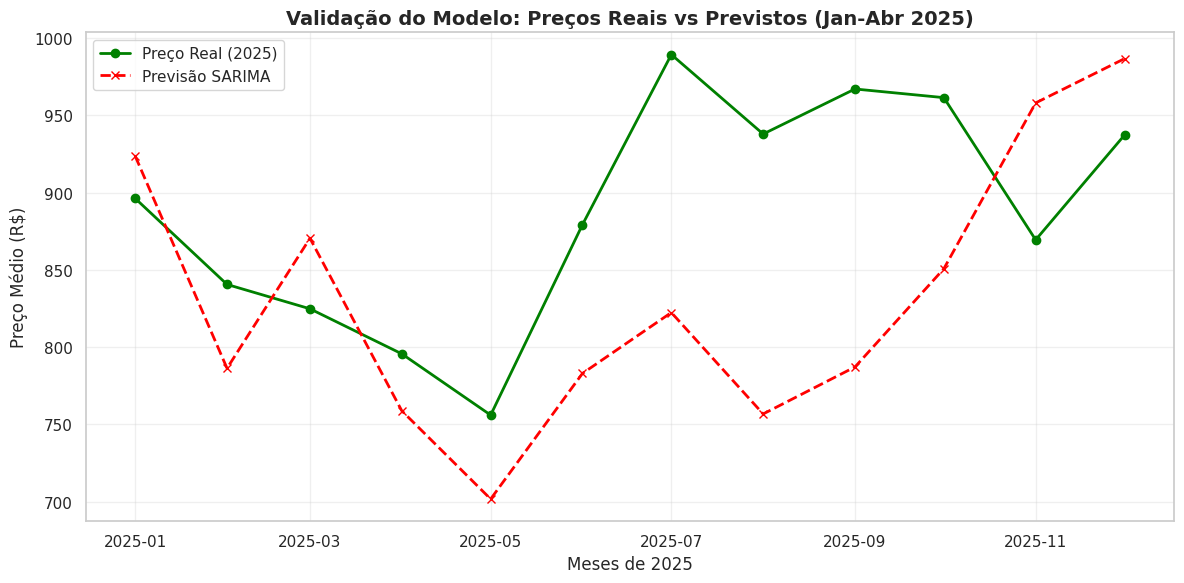

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

serie_temporal = df_completo.groupby('data')['tarifa'].mean()
serie_temporal.index = pd.to_datetime(serie_temporal.index)
serie_temporal = serie_temporal.sort_index()

train = serie_temporal[serie_temporal.index.year < 2025]
test = serie_temporal[serie_temporal.index.year == 2025]

model = SARIMAX(train,
                order=(1,1,1),
                seasonal_order=(1,1,1,12),
                enforce_stationarity=False,
                enforce_invertibility=False)

resultado = model.fit(disp=False)

pred = resultado.predict(start=test.index[0], end=test.index[-1])
rmse = np.sqrt(mean_squared_error(test, pred))

print(f'Métrica de Erro - RMSE: {rmse:.2f}')

plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Preço Real (2025)', color='green', marker='o', linewidth=2)
plt.plot(test.index, pred, label='Previsão SARIMA', color='red', linestyle='--', marker='x', linewidth=2)

plt.title('Validação do Modelo: Preços Reais vs Previstos (Jan-Abr 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Meses de 2025')
plt.ylabel('Preço Médio (R$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

===== Tarifa média mensal =====
ADF Test
Estatística ADF: -3.9988
p-valor: 0.0014
Interpretação: Estacionária

KPSS Test
Estatística KPSS: 0.0692
p-valor: 0.1000
Interpretação: Estacionária
===== Tarifa média mensal - primeira diferença =====
ADF Test
Estatística ADF: -3.8671
p-valor: 0.0023
Interpretação: Estacionária

KPSS Test
Estatística KPSS: 0.0695
p-valor: 0.1000
Interpretação: Estacionária


/tmp/ipykernel_3655/2852478905.py:27: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(serie.dropna(), regression='c', nlags='auto')
/tmp/ipykernel_3655/2852478905.py:27: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(serie.dropna(), regression='c', nlags='auto')


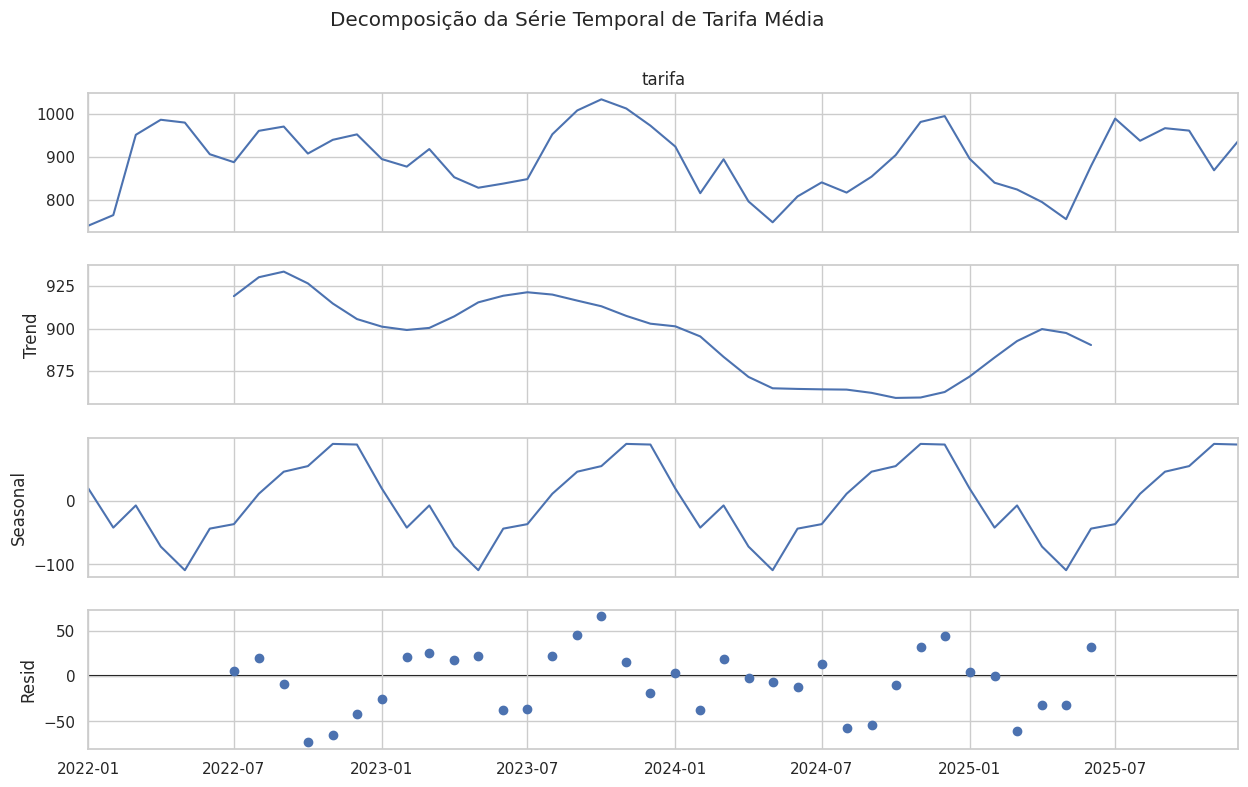

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

serie_temporal = df_completo.groupby('data')['tarifa'].mean()
serie_temporal.index = pd.to_datetime(serie_temporal.index)
serie_temporal = serie_temporal.sort_index()

serie_mensal = serie_temporal.asfreq('MS')

serie_mensal = serie_mensal.interpolate(method='time')

def teste_adf_kpss(serie, nome='Série'):
    print(f'===== {nome} =====')

    adf_result = adfuller(serie.dropna(), autolag='AIC')
    print('ADF Test')
    print(f'Estatística ADF: {adf_result[0]:.4f}')
    print(f'p-valor: {adf_result[1]:.4f}')
    print('Interpretação:', 'Estacionária' if adf_result[1] < 0.05 else 'Não estacionária')

    print('\nKPSS Test')

    try:
        kpss_result = kpss(serie.dropna(), regression='c', nlags='auto')
        print(f'Estatística KPSS: {kpss_result[0]:.4f}')
        print(f'p-valor: {kpss_result[1]:.4f}')
        print('Interpretação:', 'Não estacionária' if kpss_result[1] < 0.05 else 'Estacionária')
    except Exception as e:
        print(f'Não foi possível executar KPSS: {e}')

teste_adf_kpss(serie_mensal, 'Tarifa média mensal')

serie_diff = serie_mensal.diff().dropna()
teste_adf_kpss(serie_diff, 'Tarifa média mensal - primeira diferença')

from statsmodels.tsa.seasonal import seasonal_decompose

decomposicao = seasonal_decompose(serie_mensal, model='additive', period=12)

fig = decomposicao.plot()
fig.set_size_inches(14, 8)
plt.suptitle('Decomposição da Série Temporal de Tarifa Média', y=1.02)
plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

mae_sarima = mean_absolute_error(test, pred)
rmse_sarima = np.sqrt(mean_squared_error(test, pred))
mape_sarima = mean_absolute_percentage_error(test, pred) * 100

metricas_sarima = pd.DataFrame({
    'Modelo': ['SARIMA base'],
    'MAE': [mae_sarima],
    'RMSE': [rmse_sarima],
    'MAPE (%)': [mape_sarima]
})


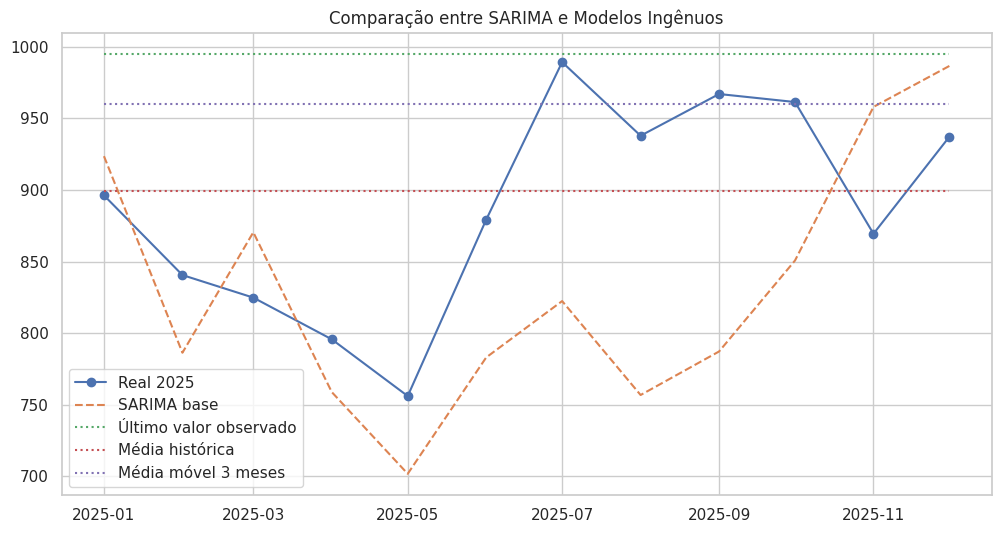

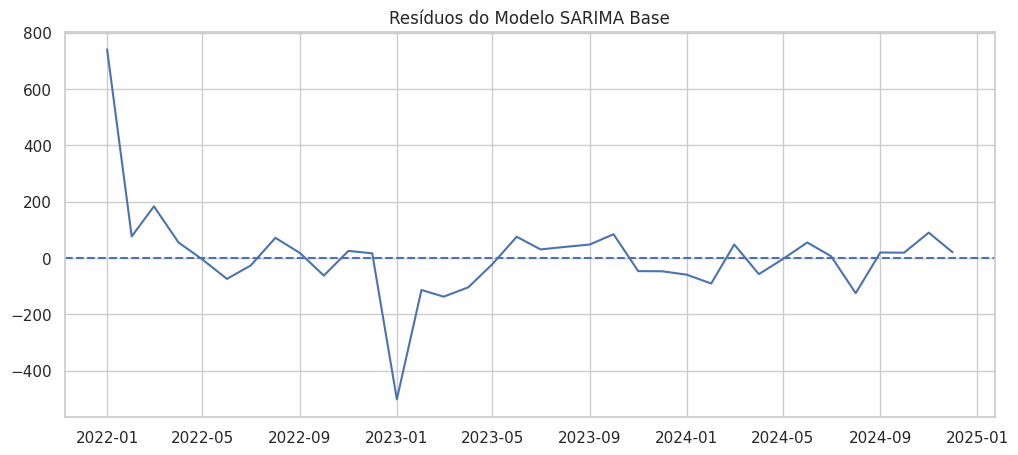

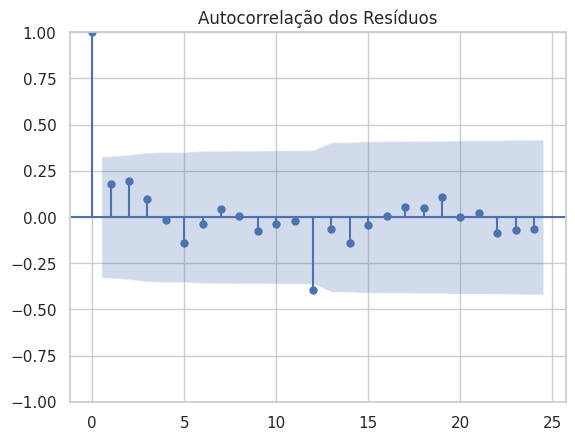

,lb_stat,lb_pvalue
12,13.414053,0.339677


In [ ]:
pred_ultimo_valor = pd.Series(train.iloc[-1], index=test.index)

pred_media_historica = pd.Series(train.mean(), index=test.index)

pred_media_movel_3m = pd.Series(train.tail(3).mean(), index=test.index)

def calcular_metricas(nome_modelo, y_true, y_pred):
    return {
        'Modelo': nome_modelo,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE (%)': mean_absolute_percentage_error(y_true, y_pred) * 100
    }

comparacao_modelos = pd.DataFrame([
    calcular_metricas('SARIMA base', test, pred),
    calcular_metricas('Último valor observado', test, pred_ultimo_valor),
    calcular_metricas('Média histórica', test, pred_media_historica),
    calcular_metricas('Média móvel 3 meses', test, pred_media_movel_3m)
]).sort_values('RMSE')

comparacao_modelos

plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Real 2025', marker='o')
plt.plot(test.index, pred, label='SARIMA base', linestyle='--')
plt.plot(test.index, pred_ultimo_valor, label='Último valor observado', linestyle=':')
plt.plot(test.index, pred_media_historica, label='Média histórica', linestyle=':')
plt.plot(test.index, pred_media_movel_3m, label='Média móvel 3 meses', linestyle=':')
plt.title('Comparação entre SARIMA e Modelos Ingênuos')
plt.legend()
plt.show()

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

residuos = resultado.resid.dropna()

plt.figure(figsize=(12,5))
plt.plot(residuos)
plt.axhline(0, linestyle='--')
plt.title('Resíduos do Modelo SARIMA Base')
plt.show()

plot_acf(residuos, lags=min(24, len(residuos)-1))
plt.title('Autocorrelação dos Resíduos')
plt.show()

ljung_box = acorr_ljungbox(residuos, lags=[12], return_df=True)
ljung_box



Melhor order: (0, 1, 1)
Melhor seasonal_order: (0, 1, 1, 12)


,Modelo,MAE,RMSE,MAPE (%)
1,SARIMA otimizado por AIC,65.817087,77.063250,7.355452
0,SARIMA base,90.945217,106.034132,9.963992


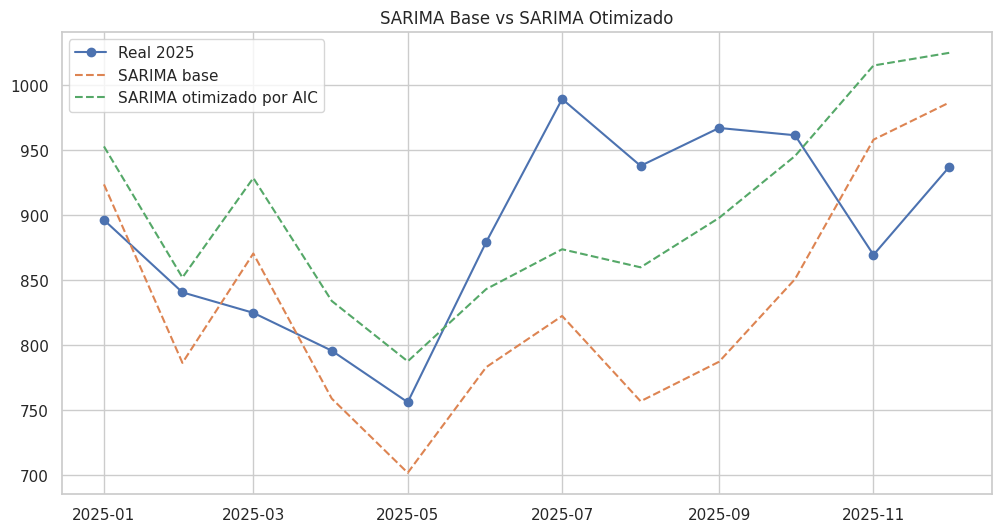

In [ ]:
import itertools
import warnings

warnings.filterwarnings('ignore')

p = d = q = range(0, 2)
pdq = list(itertools.product(p, [1], q))
seasonal_pdq = list(itertools.product(range(0, 2), [1], range(0, 2), [12]))

resultados_parametros = []

for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            modelo_teste = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            ajuste_teste = modelo_teste.fit(disp=False)
            resultados_parametros.append({
                'order': order,
                'seasonal_order': seasonal_order,
                'AIC': ajuste_teste.aic
            })
        except Exception:
            continue

df_parametros = pd.DataFrame(resultados_parametros).sort_values('AIC').reset_index(drop=True)
df_parametros.head(10)

if len(df_parametros) > 0:
    melhor_order = df_parametros.loc[0, 'order']
    melhor_seasonal_order = df_parametros.loc[0, 'seasonal_order']

    modelo_otimizado = SARIMAX(
        train,
        order=melhor_order,
        seasonal_order=melhor_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    resultado_otimizado = modelo_otimizado.fit(disp=False)
    pred_otimizado = resultado_otimizado.predict(start=test.index[0], end=test.index[-1])

    comparacao_otimizado = pd.DataFrame([
        calcular_metricas('SARIMA base', test, pred),
        calcular_metricas('SARIMA otimizado por AIC', test, pred_otimizado)
    ]).sort_values('RMSE')

    print(f'Melhor order: {melhor_order}')
    print(f'Melhor seasonal_order: {melhor_seasonal_order}')
    display(comparacao_otimizado)

    plt.figure(figsize=(12,6))
    plt.plot(test.index, test, label='Real 2025', marker='o')
    plt.plot(test.index, pred, label='SARIMA base', linestyle='--')
    plt.plot(test.index, pred_otimizado, label='SARIMA otimizado por AIC', linestyle='--')
    plt.title('SARIMA Base vs SARIMA Otimizado')
    plt.legend()
    plt.show()
else:
    print('Nenhum modelo válido foi encontrado na busca de parâmetros.')

previsoes_janela_movel = []

for data_teste in test.index:
    treino_movel = serie_mensal[serie_mensal.index < data_teste]

    try:
        modelo_movel = SARIMAX(
            treino_movel,
            order=(1,1,1),
            seasonal_order=(1,1,1,12),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        resultado_movel = modelo_movel.fit(disp=False)
        previsao = resultado_movel.forecast(steps=1).iloc[0]
    except Exception:
        previsao = np.nan

    previsoes_janela_movel.append(previsao)

pred_janela_movel = pd.Series(previsoes_janela_movel, index=test.index).dropna()
test_janela_movel = test.loc[pred_janela_movel.index]

metricas_janela_movel = pd.DataFrame([
    calcular_metricas('SARIMA base - previsão direta 2025', test, pred),
    calcular_metricas('SARIMA base - janela móvel', test_janela_movel, pred_janela_movel)
])


# **Método Aplicado**

Foi utilizado um modelo estatístico da classe SARIMA (Seasonal AutoRegressive Integrated Moving Average), adequado para séries temporais que apresentam tendência e sazonalidade (características identificadas nos dados analisados).

A modelagem considerou:

* Componentes autoregressivos e de média móvel
* Diferenciação para garantir estacionariedade
* Sazonalidade mensal

Para validação do modelo, foram utilizados dois métodos:

* Previsão direta (holdout)
* Treinamento com dados históricos
* Previsão para o período de 2025
* Validação com janela móvel (rolling window)
* Simulação do uso real do modelo
* Re-treinamento contínuo ao longo do tempo

# **Análise dos Resultados**

Os resultados obtidos foram:

| Modelo                   | MAE  | RMSE  | MAPE  |
|--------------------------|------|-------|-------|
| SARIMA – previsão direta | 90,9 | 106,0 | 9,96% |
| SARIMA – janela móvel    | 63,9 | 79,1  | 7,19% |

A abordagem com janela móvel apresentou desempenho superior, reduzindo:

* o erro absoluto (MAE) em aproximadamente 30%
* o erro quadrático (RMSE) em aproximadamente 25%
* o erro percentual (MAPE) para cerca de 7,2%


# **Cronograma**

### 3. Cronograma de Atividades

| Etapa | Data Limite | Atividades Principais | Status |
| :--- | :---: | :--- | :---: |
| **Etapa 1** | 01/03 | Definição do tema e organização do GitHub. | Concluído |
| **Etapa 2** | 29/03 | Ingestão, Pipeline e EDA (26M registros). | Concluído |
| **Etapa 3** | 26/04 | Implementação de modelos preditivos (SARIMA/LSTM). | Concluído |
| **Etapa 4** | 31/05 | Análise crítica dos resultados e Entrega final. | Em Aberto |


# **Referências**

AGÊNCIA NACIONAL DE AVIAÇÃO CIVIL (ANAC). Microdados de Tarifas Aéreas Comercializadas. Brasília, DF: ANAC, 2024. Disponível em: https://www.gov.br/anac/pt-br/assuntos/dados-e-estatisticas/microdados-de-tarifas-aereas-comercializadas. Acesso em: 15 abr. 2026.

HUNTER, J. D. Matplotlib: A 2D graphics environment. Computing in Science & Engineering, v. 9, n. 3, p. 90-95, 2007.

MCKINNEY, W. Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython. 3. ed. Sebastopol: O'Reilly Media, 2022.

PANDAS DEVELOPMENT TEAM. pandas-dev/pandas: Pandas 2.2.0. Zenodo, 2024. Disponível em: https://pandas.pydata.org. Acesso em: 15 abr. 2026.

WASKOM, M. L. Seaborn: statistical data visualization. Journal of Open Source Software, v. 5, n. 52, p. 2121, 2020.
BOX, G. E. P. et al. Time Series Analysis: Forecasting and Control. 5. ed. Hoboken: Wiley, 2015.

HYNDMAN, R. J.; ATHANASOPOULOS, G. Forecasting: Principles and Practice. 3. ed. Melbourne: OTexts, 2021. Disponível em: https://otexts.com/fpp3/. Acesso em: 26 abr. 2026.



In [ ]:
#@title **Avaliação**
EDA_e_preprocessamento = 10 #@param {type:"slider", min:0, max:10, step:1}

Modelo_base = 10 #@param {type:"slider", min:0, max:10, step:1}

In [ ]:
#@title **Nota Final**
nota = 0.50*EDA_e_preprocessamento + 0.50*Modelo_base

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 10.0


NameError: name 'Aluno5' is not defined